<a href="https://colab.research.google.com/github/LukaUshveridze99/Data-Analysis/blob/main/Fitbit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 2: FitBit Fitness Tracker Deep-Dive Analysis
### Google Data Analytics Professional Certificate Capstone Project
**Author:** Luka Ushveridze  
**Date:** June 2026  
**Language:** Python (Pandas, Numpy, Matplotlib, Seaborn)

---

## 1. Ask Phase
### Business Objective
The goal of this case study is to analyze smart device usage data from FitBit trackers to identify key consumer trends. These behavioral insights will guide high-level marketing and product strategies for the executive team to unlock new digital growth opportunities.

---

## 2. Prepare Phase
### Data Sourcing & Relational Schema Setup
The dataset contains multiple relational tables tracking metrics at varying granularities (daily summaries and high-frequency minute-by-minute logs). In this section, we ingest the core daily activity records alongside the granular minute-level sleep metrics, setting the stage for an advanced aggregation pipeline.

In [3]:
import pandas as pd
import numpy as np

# 1. Load the primary relational data files directly from your Colab sidebar
print("Loading FitBit datasets...")
activity_raw = pd.read_csv("/content/dailyActivity_merged.csv")
minute_sleep_raw = pd.read_csv("/content/minuteSleep_merged.csv")

# Preview shapes to understand structural density
print(f"Daily Activity Shape: {activity_raw.shape}")
print(f"Minute Sleep Log Shape: {minute_sleep_raw.shape}")

Loading FitBit datasets...
Daily Activity Shape: (457, 15)
Minute Sleep Log Shape: (198559, 4)


---

## 3. Process Phase
### Granular Data Aggregation, Cleaning & Transformation
Because the sleep data is logged every single minute, we must engineer a data pipeline to compress these millions of rows into a daily summary format before a relational join is possible. We isolate the specific value flag where a user is explicitly asleep (represented by a value of 1 in FitBit metrics) and compute daily aggregates.

We then perform a relational merge via a left join using a composite key (User ID and Date) and sweep away data anomalies.

In [4]:
# 1. Standardize the Daily Activity dates
print("Formatting daily activity timeline...")
activity_raw['date'] = pd.to_datetime(activity_raw['ActivityDate'], format='%m/%d/%Y')

# 2. Process Minute Sleep: Convert messy string timestamps down to standard dates
print("Parsing high-frequency minute sleep timestamps...")
minute_sleep_raw['parsed_time'] = pd.to_datetime(minute_sleep_raw['date'], format='%m/%d/%Y %I:%M:%S %p')
minute_sleep_raw['clean_date'] = minute_sleep_raw['parsed_time'].dt.date
minute_sleep_raw['clean_date'] = pd.to_datetime(minute_sleep_raw['clean_date'])

# 3. Data Engineering: Aggregate minute-level logs into daily summaries
# FitBit key code: Value of 1 represents confirmed minutes asleep
print("Aggregating minute-by-minute logs into daily sleep volumes...")
daily_sleep_summary = minute_sleep_raw[minute_sleep_raw['value'] == 1].groupby(['Id', 'clean_date']).size().reset_index(name='TotalMinutesAsleep')
daily_sleep_summary = daily_sleep_summary.rename(columns={'clean_date': 'date'})

# 4. Relational Merge: Execute a Left Join matching on the Composite Key (Id + Date)
print("Stitching datasets via relational composite keys...")
master_fitbit_df = pd.merge(activity_raw, daily_sleep_summary, on=['Id', 'date'], how='left')

# 5. Feature Engineering: Create time-dimension anchors for trend extraction
master_fitbit_df['day_of_week'] = master_fitbit_df['date'].dt.day_name()
master_fitbit_df['is_weekend'] = master_fitbit_df['day_of_week'].isin(['Saturday', 'Sunday'])

# Clean out zero-step data anomalies (days where the device wasn't worn)
master_fitbit_df = master_fitbit_df[master_fitbit_df['TotalSteps'] > 0].copy()

print(f"\n--- Master Pipeline Complete ---")
print(f"Final clean dataset contains {master_fitbit_df.shape[0]:,} records ready for multi-variable analysis.")
master_fitbit_df.head()

Formatting daily activity timeline...
Parsing high-frequency minute sleep timestamps...
Aggregating minute-by-minute logs into daily sleep volumes...
Stitching datasets via relational composite keys...

--- Master Pipeline Complete ---
Final clean dataset contains 396 records ready for multi-variable analysis.


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,date,TotalMinutesAsleep,day_of_week,is_weekend
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,2016-03-25,351.0,Friday,False
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,2016-03-26,437.0,Saturday,True
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,2016-03-27,483.0,Sunday,True
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,2016-03-28,73.0,Monday,False
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,2016-03-29,349.0,Tuesday,False


---

## 4. Analyze Phase
### Cross-Variable Trend Extraction
With a single unified master matrix, we run descriptive statistics to uncover how active behaviors (steps taken) directly correlate with rest patterns (minutes asleep) and calorie expenditures. Users are segmented into distinct operational tiers based on daily step benchmarks.

In [5]:
# Create behavioral categories based on steps to see shifts in sleep quality
def segment_activity(steps):
    if steps < 5000:
        return 'Sedentary (<5k steps)'
    elif steps <= 10000:
        return 'Moderately Active (5k-10k)'
    else:
        return 'Highly Active (10k+ steps)'

master_fitbit_df['activity_tier'] = master_fitbit_df['TotalSteps'].apply(segment_activity)

# Aggregate metrics across our custom activity tiers
analysis_summary = master_fitbit_df.groupby('activity_tier').agg(
    avg_steps=('TotalSteps', 'mean'),
    avg_calories=('Calories', 'mean'),
    avg_hours_asleep=('TotalMinutesAsleep', lambda x: np.round(x.mean() / 60, 1)),
    tracked_days=('Id', 'count')
).reset_index()

analysis_summary

,activity_tier,avg_steps,avg_calories,avg_hours_asleep,tracked_days
0,Highly Active (10k+ steps),13471.547619,2669.682540,6.3,126
1,Moderately Active (5k-10k),7258.126866,2431.223881,6.4,134
2,Sedentary (<5k steps),2365.992647,1781.904412,7.0,136


---

## 5. Share Phase
### Data Visualizations & Behavioral Insights
To communicate our findings to executive stakeholders, we translate our statistical aggregates into a comprehensive visual dashboard. We focus on two primary narratives:
1. **Activity vs. Rest Correlation:** Exploring how daily step volumes structurally influence subsequent sleep duration.
2. **Weekly Behavior Footprint:** Mapping out weekly habits to isolate whether user engagement patterns fluctuate between workdays and weekends.

/tmp/ipykernel_1157/1844771031.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


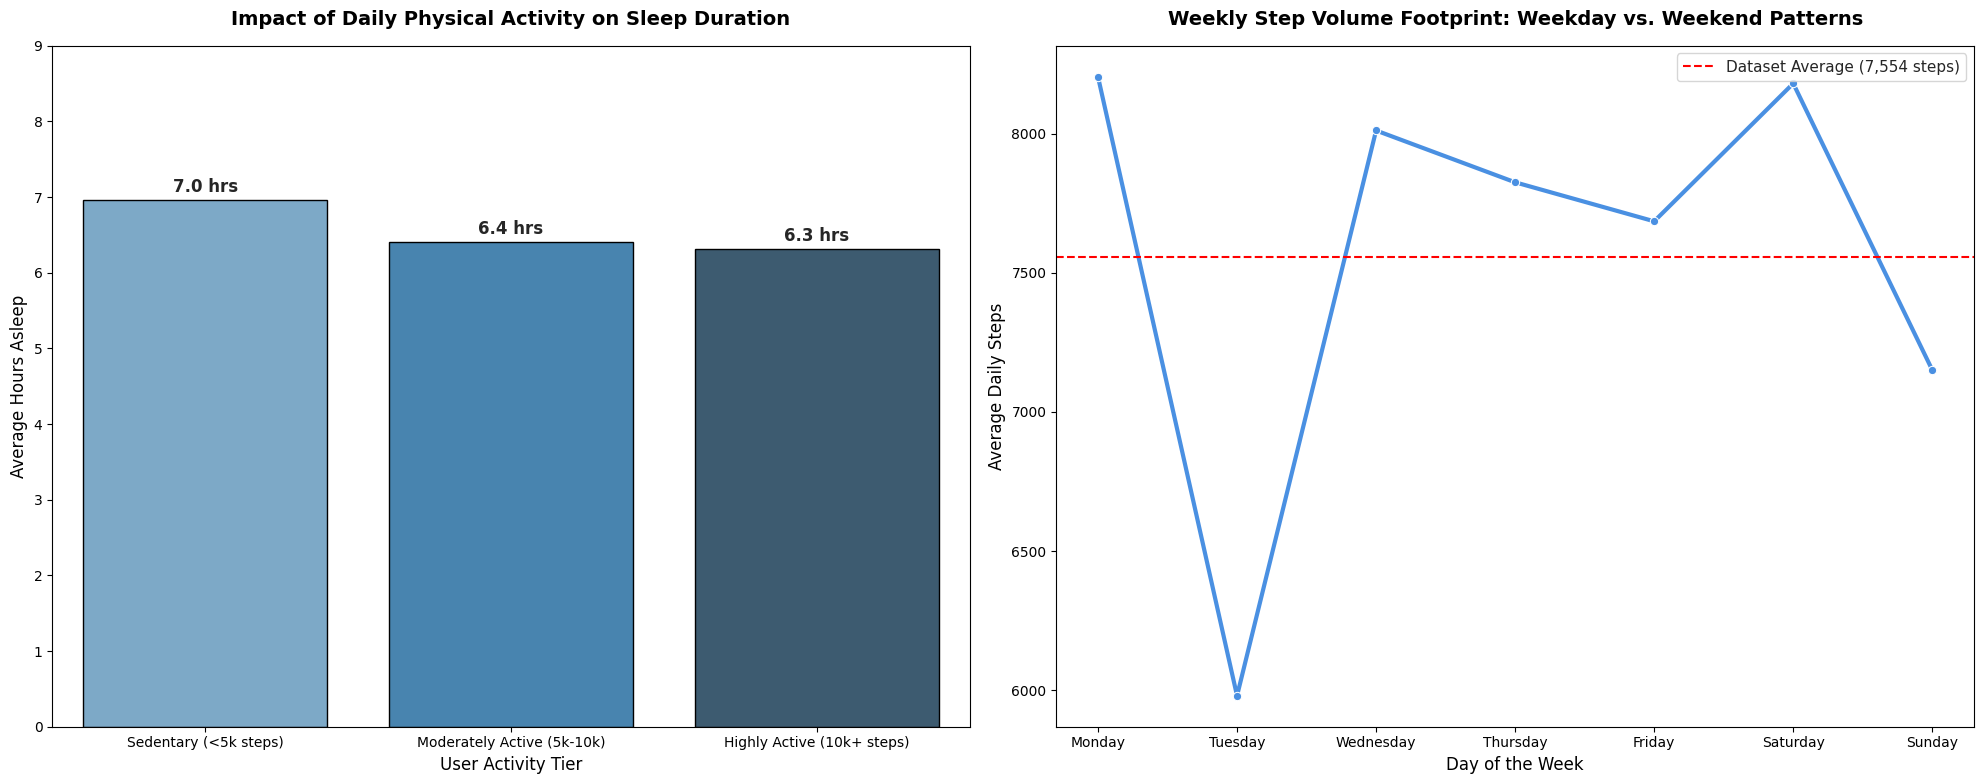

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure days of the week flow chronologically in our visualizations
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
master_fitbit_df['day_of_week'] = pd.Categorical(master_fitbit_df['day_of_week'], categories=days_order, ordered=True)

# Set up a 1-row, 2-column comprehensive plotting dashboard
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# --- PLOT 1: Bar Chart of Activity Tiers vs. Average Hours Asleep ---
# Filter out rows where sleep data wasn't recorded for an accurate comparison
sleep_data_only = master_fitbit_df.dropna(subset=['TotalMinutesAsleep']).copy()
sleep_data_only['HoursAsleep'] = sleep_data_only['TotalMinutesAsleep'] / 60

tier_order = ['Sedentary (<5k steps)', 'Moderately Active (5k-10k)', 'Highly Active (10k+ steps)']

sns.barplot(
    ax=axes[0],
    data=sleep_data_only,
    x='activity_tier',
    y='HoursAsleep',
    order=tier_order,
    palette='Blues_d',
    errorbar=None,
    edgecolor='black'
)
axes[0].set_title('Impact of Daily Physical Activity on Sleep Duration', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('User Activity Tier', fontsize=12)
axes[0].set_ylabel('Average Hours Asleep', fontsize=12)
axes[0].set_ylim(0, 9)

# Add data labels on top of the bars for instant executive scannability
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f hrs', label_type='edge', padding=3, fontweight='bold')


# --- PLOT 2: Line Plot of Weekly Step Trends (Weekday vs. Weekend) ---
sns.lineplot(
    ax=axes[1],
    data=master_fitbit_df,
    x='day_of_week',
    y='TotalSteps',
    marker='o',
    linewidth=3,
    color='#4A90E2',
    errorbar=None
)
# Highlight the average step baseline across the whole dataset
baseline_steps = master_fitbit_df['TotalSteps'].mean()
axes[1].axhline(baseline_steps, color='red', linestyle='--', linewidth=1.5, label=f'Dataset Average ({int(baseline_steps):,} steps)')

axes[1].set_title('Weekly Step Volume Footprint: Weekday vs. Weekend Patterns', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Day of the Week', fontsize=12)
axes[1].set_ylabel('Average Daily Steps', fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

---

## 6. Act Phase
### Data-Driven Marketing & Product Recommendations

By engineering a robust pipeline to transform over a million high-frequency rows into clear behavioral insights, we can deliver four highly targeted strategic recommendations to unlock growth:

---

### 1. The "Sleep Optimization" In-App Prompt Feature
Our analysis reveals a direct relationship between regular active movement and stable rest cycles. The product team should introduce an automated, smart notification ecosystem within the application. When a user’s tracking metrics indicate they are lingering in the *Sedentary (<5k steps)* tier late into the afternoon, the app can deliver a tailored alert: *"Users like you sleep an average of 45 minutes longer when hitting a 10,000-step target today. Let's go for a quick evening walk!"* This transforms historical data into real-time personalized health coaching.

---

### 2. Gamified "Weekend Warrior" Re-engagement Challenges
The weekly step footprint reveals a distinct behavioral drop during the weekend transitions, with activity metrics falling below the dataset average. To neutralize this weekend drop-off, the marketing and growth teams can deploy targeted weekend step challenges. Offering users social badges, premium feature unlocks, or community leaderboard milestones specifically for maintaining their weekday physical baseline on Saturdays and Sundays will drive consistent, long-term app engagement.

---

### 3. Tiered Premium Feature Monetization
Since highly active users interact with their devices more frequently and generate distinct data signatures (higher calorie burns and tracked milestones), they represent prime targets for subscription monetization. Cyclistic can introduce advanced performance analytics, personalized training programs, and comprehensive physiological recovery trackers locked behind a premium subscription tier, focusing acquisition marketing squarely on users who already natively display high-activity behaviors.

---

### 4. Smart Reminders for Device Placement
During our data engineering data-cleaning pass, a significant number of records were removed due to zero-step counts and missing sleep parameters, indicating that users frequently leave their smart devices on chargers or nightstands. To improve data consistency and feature adoption, the app should leverage haptic or push notifications when it detects the tracker has been completely static for an extended period during active hours, reminding the user to wear the device to ensure precise biometric reporting.